Define Problem Statement and perform Exploratory Data Analysis (10 points)
- Definition of problem (as per given problem statement with additional views)
- Observations on shape of data, data types of all the attributes, conversion of categorical attributes to 'category' (If required) , missing value detection, statistical summary.
- Univariate Analysis (distribution plots of all the continuous variable(s) barplots/countplots of all the categorical variables)
- Bivariate Analysis (Relationships between important variables such as workday and count, season and count, weather and count.
- Illustrate the insights based on EDA
- Comments on range of attributes, outliers of various attributes
- Comments on the distribution of the variables and relationship between them
- Comments for each univariate and bivariate plots
- Hypothesis Testing (30 Points):
  - 2- Sample T-Test to check if Working Day has an effect on the number of electric cycles rented (10 points)
  - ANNOVA to check if No. of cycles rented is similar or different in different 1. weather 2. season (10 points)
  - Chi-square test to check if Weather is dependent on the season (10 points)

Column Profiling:

- datetime: datetime
- season: season (1: spring, 2: summer, 3: fall, 4: winter)
holiday: whether day is a holiday or not (extracted from http://dchr.dc.gov/page/holiday-schedule)
- workingday: if day is neither weekend nor holiday is 1, otherwise is 0.
weather:
  - 1: Clear, Few clouds, partly cloudy, partly cloudy
  - 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
  - 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
  - 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
- temp: temperature in Celsius
- atemp: feeling temperature in Celsius
- humidity: humidity
- windspeed: wind speed
- casual: count of casual users
- registered: count of registered users
- count: count of total rental bikes including both casual and registered

# Business Case

Yulu has recently suffered considerable dips in its revenues. They have contracted a consulting company to understand the factors on which the demand for these shared electric cycles depends. Specifically, they want to understand the factors affecting the demand for these shared electric cycles in the Indian market.


How you can help here?

The company wants to know:

- Which variables are significant in predicting the demand for shared electric cycles in the Indian market?
- How well those variables describe the electric cycle demands

# Will approach the problem in a systematic framework

1. Defining the Problem
2. Data Cleaning and Preparation
3. Exploratory Data Visualization
4. Hypothesis Testing
4. Summarize and Recommendations

# 1. Defining the Problem

#### a) Understanding the important parameters impacting the demand of the electric cycles

#### b) Based on the inferences, providing business recommendations with an possible outcome to improve the demand and thus generating revenue for the organization

# 2. Data Cleaning and Preparation

#### a) Understanding the data using summarization functions

#### b) Outliers, Null values treatment

In [107]:
!pip install pingouin

In [159]:
# Importing all the required libraries


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as  sns
import io
import pingouin as pg
from scipy.stats import ttest_ind,ttest_rel,ttest_1samp,f_oneway,chi2_contingency,pearsonr,spearmanr,kruskal,shapiro,levene

In [109]:
df = pd.read_csv('/content/drive/MyDrive/1. Rahul/Training/Scalar_Data_Science&ML/4.Business_Case_Study/Yulu_Data.csv')

In [110]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [111]:
df.shape

(10886, 12)

In [112]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


Interpretation
- The dataframe consits of 10886 rows and 12 columns
- None of the columns or features are null
- Temperature varies from 0.82 to 41 degree celcius with a mean of 20, similarly feeling temperature also ranges from 0.76 to 45, with a mean of 23 degree celcius
- Number of casual users has a wide range from 0 to 367, however registered users are 3 times of the casual users
- Data Types: All columns have appropriate data types except for datetime, which is currently an object type. This will need to be converted to a datetime object for time-series analysis.
- The count column has a wide range (1 to 977) and a relatively high standard deviation (181.14) compared to its mean (191.57), suggesting a dispersed distribution. This is also evident from the large difference between the 75th percentile (284) and the maximum value (977), hinting at potential outliers or a skewed distribution.
- The minimum windspeed is 0, which might be an indicator of missing or recorded data points where windspeed was not measured or was negligible

## Data Preprocessing and Cleaning

In [114]:
# datetime is currentlty in object will convert into datetime data type

df['datetime'] = pd.to_datetime(df['datetime'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory usage: 1020.7 KB


In [115]:
# Checking windspeed

df['windspeed'].value_counts()

,count
windspeed,
0.0000,1313
8.9981,1120
11.0014,1057
12.9980,1042
7.0015,1034
15.0013,961
6.0032,872
16.9979,824
19.0012,676


In [116]:
# There are 1313 rows with zero windspeed which is impossible as we cannot survive if wind is not there, so its a case of missing value.

#Either we can drop, but it constitutes 10% of the overall data which is a significant data

# Since this is a continous data, lets substitute with either mean, median or mode

print("mode of the windspeed column is: ",df['windspeed'].mode())
print("median of the windspeed column is: ",df['windspeed'].median())
print("mean of the windspeed column is: ",df['windspeed'].mean())

mode of the windspeed column is:  0    0.0
Name: windspeed, dtype: float64
median of the windspeed column is:  12.998
mean of the windspeed column is:  12.7993954069447


In [117]:
# Since median and mean are almost equal,hence would be substituting the nullvalues with median

# df['windspeed'].fillna(df['windspeed'].median(),inplace=True)

df['windspeed'] = df['windspeed'].replace(0, df['windspeed'].median())

In [118]:
# Rechecking the values
df['windspeed'].value_counts()

,count
windspeed,
12.9980,2355
8.9981,1120
11.0014,1057
7.0015,1034
15.0013,961
6.0032,872
16.9979,824
19.0012,676
19.9995,492


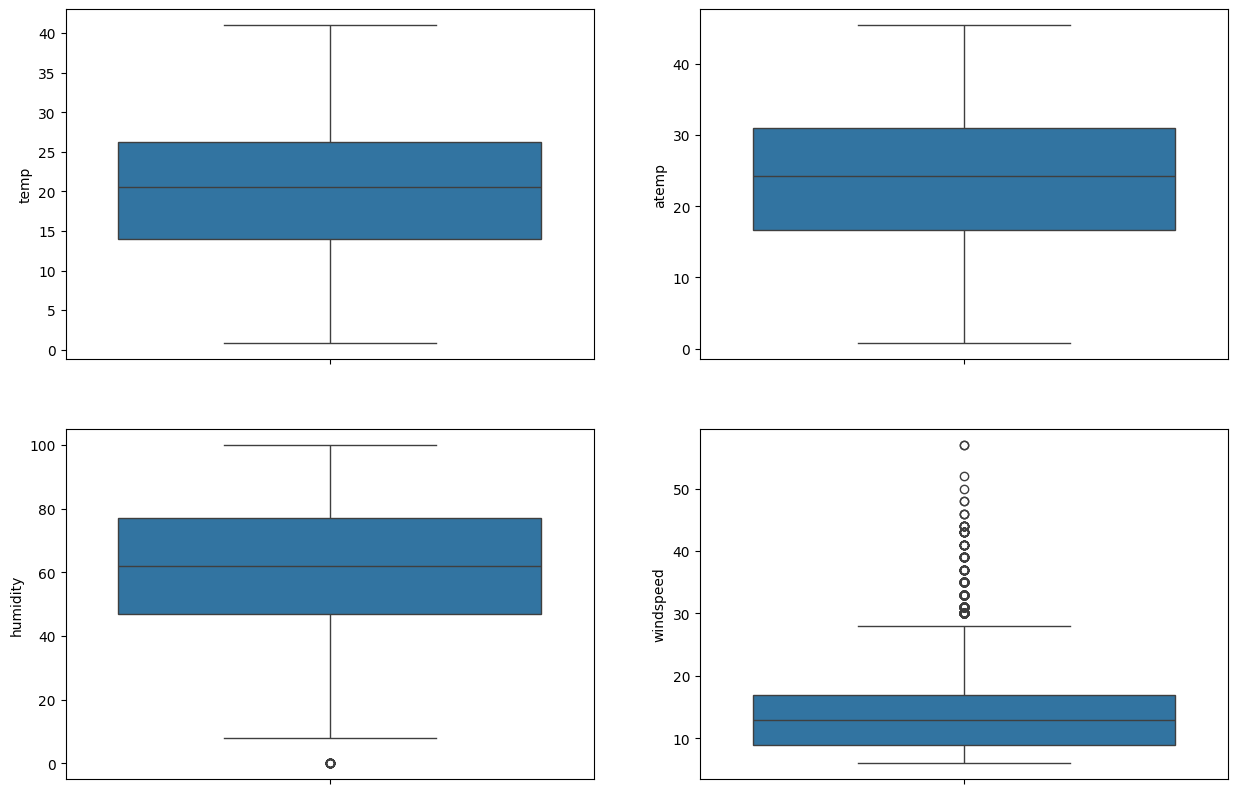

In [119]:
# Since all are continous data types,hence will check for outliers using box plot,
# features in focus (temp,atemp,humidity and windspeed)


plt.subplots(2,2,figsize=(15,10))

plt.subplot(2,2,1)
sns.boxplot(df['temp'])

plt.subplot(2,2,2)
sns.boxplot(df['atemp'])

plt.subplot(2,2,3)
sns.boxplot(df['humidity'])

plt.subplot(2,2,4)
sns.boxplot(df['windspeed'])

plt.show()




In [120]:
# as we can see from the box plot that there are no outliers for temp,atemp,
# humidity, however a large number of outliers can be seen for windspeed

# Outliers treatment for windspeed using IQR

q1 = df['windspeed'].quantile(0.25)
q3 = df['windspeed'].quantile(0.75)

IQR = q3-q1

ws_upper_whisker = q3 + 1.5 * IQR
ws_lower_whisker = q1 - 1.5 * IQR

print("Upper Whisker: ",ws_upper_whisker)
print("Lower Whisker: ",ws_lower_whisker)

Upper Whisker:  28.997600000000002
Lower Whisker:  -3.0016


In [121]:
# Lets check how many of the values are lying outside these bounds

points_outside_upper_whisker = df[df['windspeed'] > ws_upper_whisker].shape[0]
points_outside_upper_whisker

427

In [122]:
# Since there are only 427 data points its better to remove these data

df = df[~(df['windspeed'] > ws_upper_whisker)]

<Axes: ylabel='windspeed'>

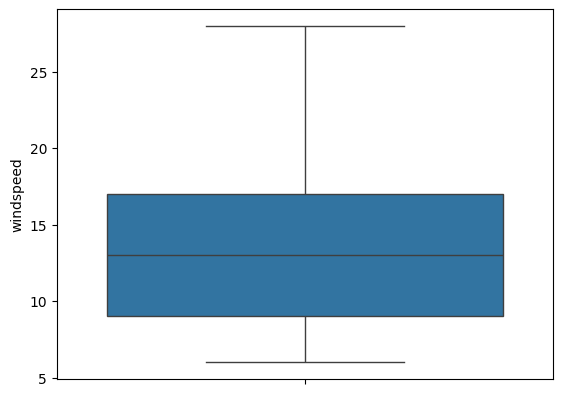

In [123]:
# now lets replot the box plot for windspeed

sns.boxplot(df['windspeed'])

In [124]:
# There are no outliers

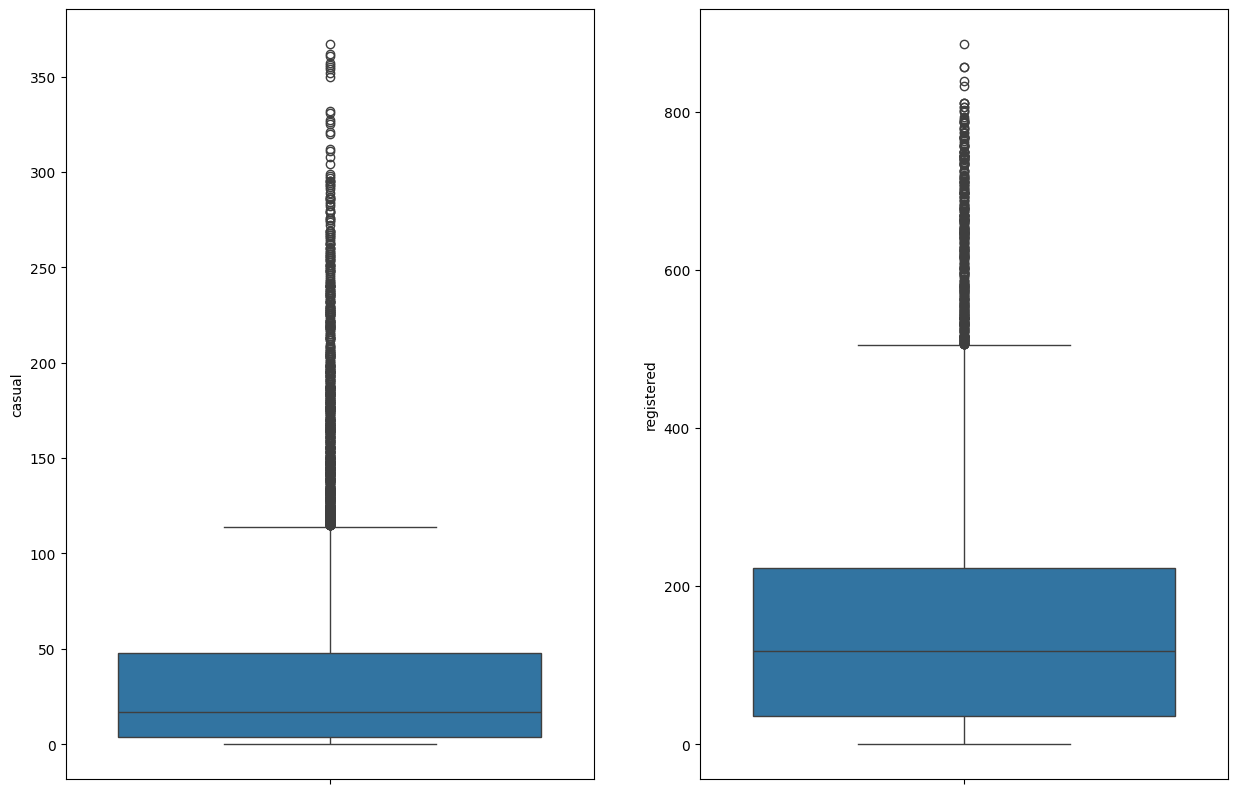

In [125]:
# lets check for other columns also

plt.subplots(1,2,figsize = (15,10))

plt.subplot(1,2,1)
sns.boxplot(df['casual'])

plt.subplot(1,2,2)
sns.boxplot(df['registered'])
plt.show()

In [126]:
# Given that the objective is to understand factors affecting demand, these high values in 'casual'
# and 'registered' counts might be important indicators of peak demand periods.
# For now, it might be best to keep them in the dataset and proceed with the exploratory data analysis. The univariate analysis will give us a better understanding of the distribution of these variables, which can help inform the decision on outlier treatment later if necessary.

# 3. Exploratory Data Analysis

#### a) Univariate Analysis (Histogram,KDEPlot)

#### b) Bi-Variate Analysis (Scatter, Pairplot,heatmap,boxplot, barplot)

## Univariate Analysis

In [127]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,12.998,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,12.998,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,12.998,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,12.998,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,12.998,0,1,1


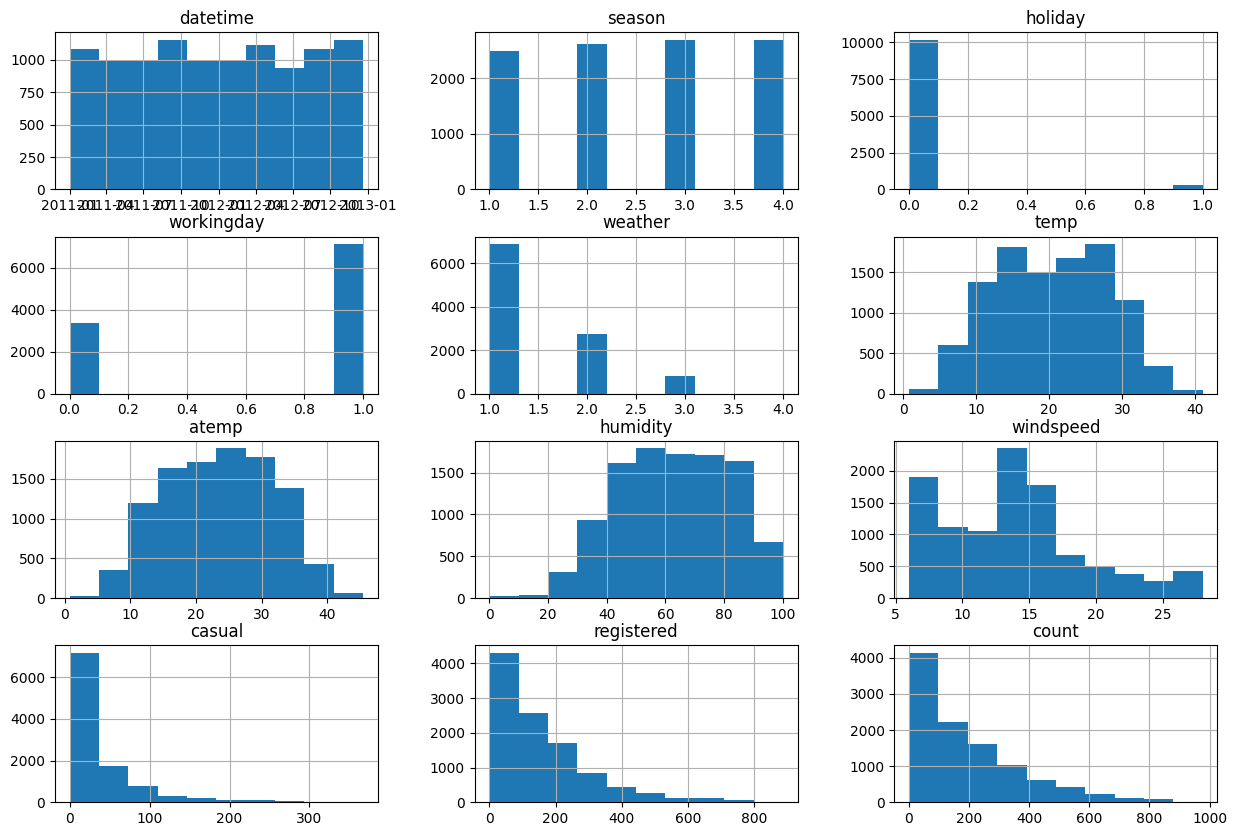

In [128]:
# Histogram

df.hist(figsize=(15,10))
plt.show()

### Inferences

- The demand is high during the weekdays, probably when people are commuting for work or college and the same can be seen from the working day graph also.
- Demand is constant across all seasons.
- In case of heavy rains there is no demand, as expected, and the demand is highest during clear weather.

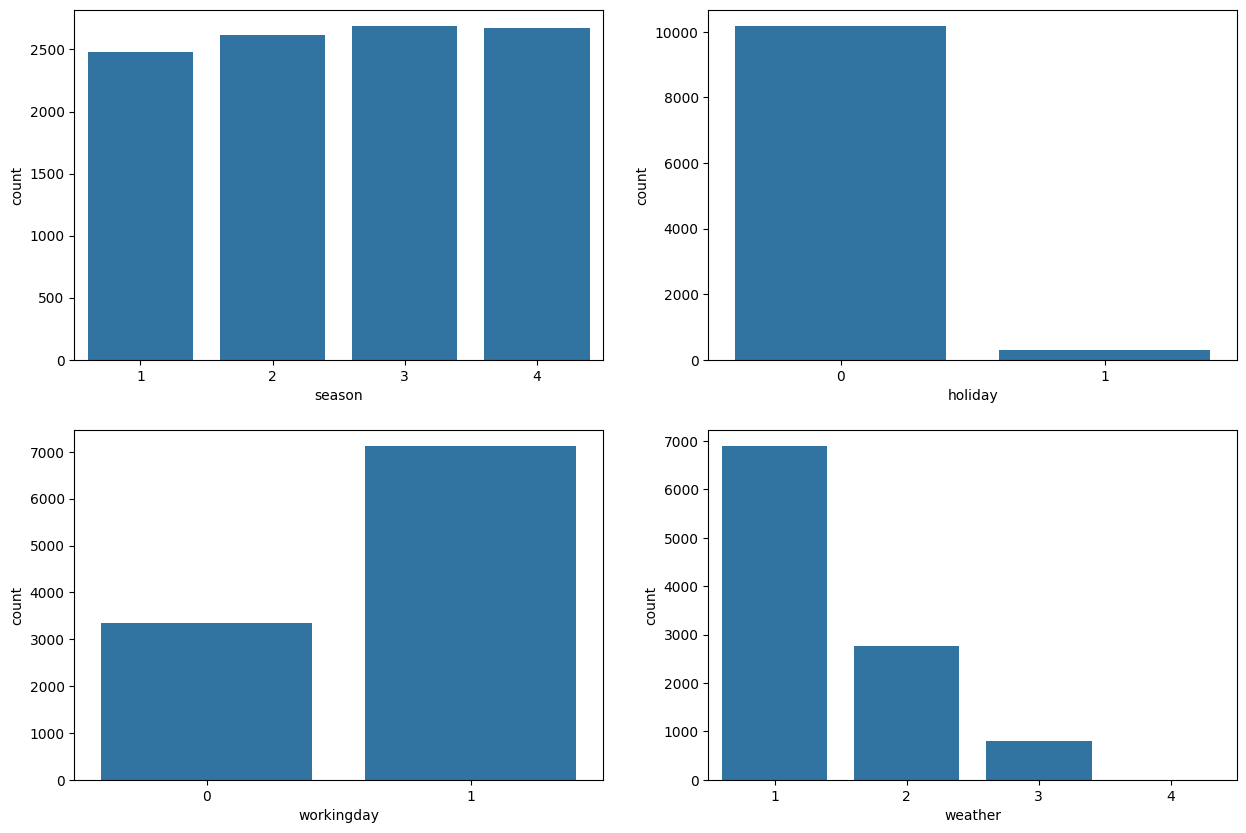

In [134]:
# Lets look at categorical variable

plt.subplots(2,2,figsize=(15,10))

plt.subplot(2,2,1)
sns.countplot(data = df,x = 'season')

plt.subplot(2,2,2)
sns.countplot(data = df,x = 'holiday')

plt.subplot(2,2,3)
sns.countplot(data = df,x = 'workingday')

plt.subplot(2,2,4)
sns.countplot(data = df,x = 'weather')

plt.show()

### Inferences

- The demand is high during the weekdays, probably when people are commuting for work or college and the same can be seen from the working day graph also.
- Demand is constant across all seasons.
- In case of heavy rains there is no demand, as expected, and the demand is highest during clear weather.

## Bivariate Analysis

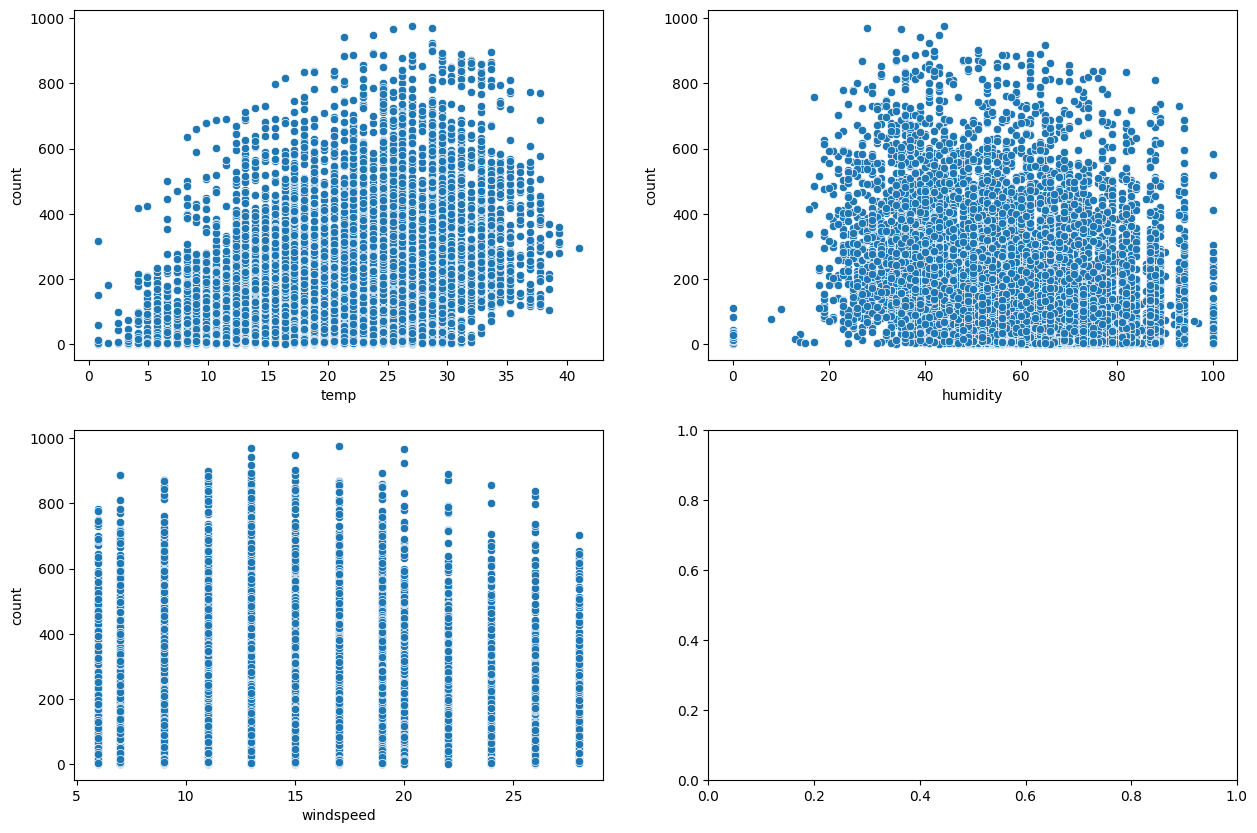

In [136]:
# Lets do it for numericaland numerical categories

plt.subplots(2,2,figsize=(15,10))

plt.subplot(2,2,1)
sns.scatterplot(data = df,x = 'temp',y = 'count')

plt.subplot(2,2,2)
sns.scatterplot(data = df,x = 'humidity',y = 'count')

plt.subplot(2,2,3)
sns.scatterplot(data = df,x = 'windspeed',y = 'count')

plt.show()


### Inferences from Scatter Plots

*   **Count vs. Temp:** The scatter plot shows a positive correlation between temperature and the count of rentals. As temperature increases, the number of rentals generally tends to increase. This is an expected relationship, as people are more likely to rent bikes in pleasant weather.
*   **Count vs. Humidity:** The scatter plot for humidity and count doesn't show a clear linear relationship. There seems to be a wide spread of rental counts across different humidity levels. It's possible that extreme humidity (very high or very low) might have some impact, but it's not a strong linear correlation.
*   **Count vs. Windspeed:** Similar to humidity, the scatter plot for windspeed and count doesn't show a strong linear relationship. While very high wind speeds might discourage rentals, there isn't a clear pattern across the range of wind speeds after handling the zero values.

In [141]:
# Extract month from the datetime column

df['month'] = df['datetime'].dt.month

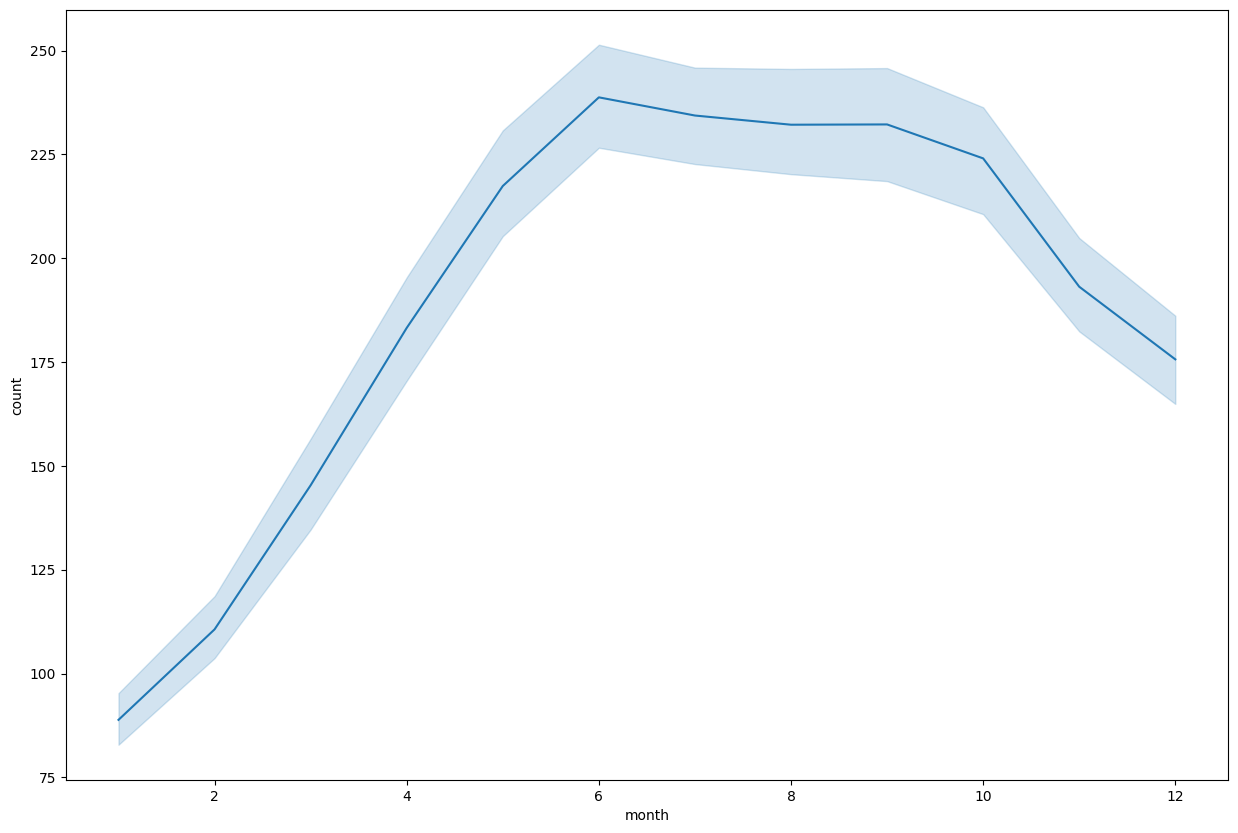

In [142]:
# line plot of counts wrt the date time


plt.figure(figsize=(15,10))
sns.lineplot(data = df,x = 'month',y = 'count')
plt.show()

### Inferences from Line Plot (Count vs. Month)

*   The line plot shows a clear seasonal trend in the rental count.
*   The demand for electric cycles starts to increase from March, peaks during the summer months (around June to September), and then starts to decrease towards the end of the year.
*   The lowest demand is observed during the winter months (around January and February).
*   This pattern aligns with the expectation that people are more likely to use shared electric cycles in warmer and more favorable weather conditions.

In [ ]:
# Lets do it for categorical and categorical categories


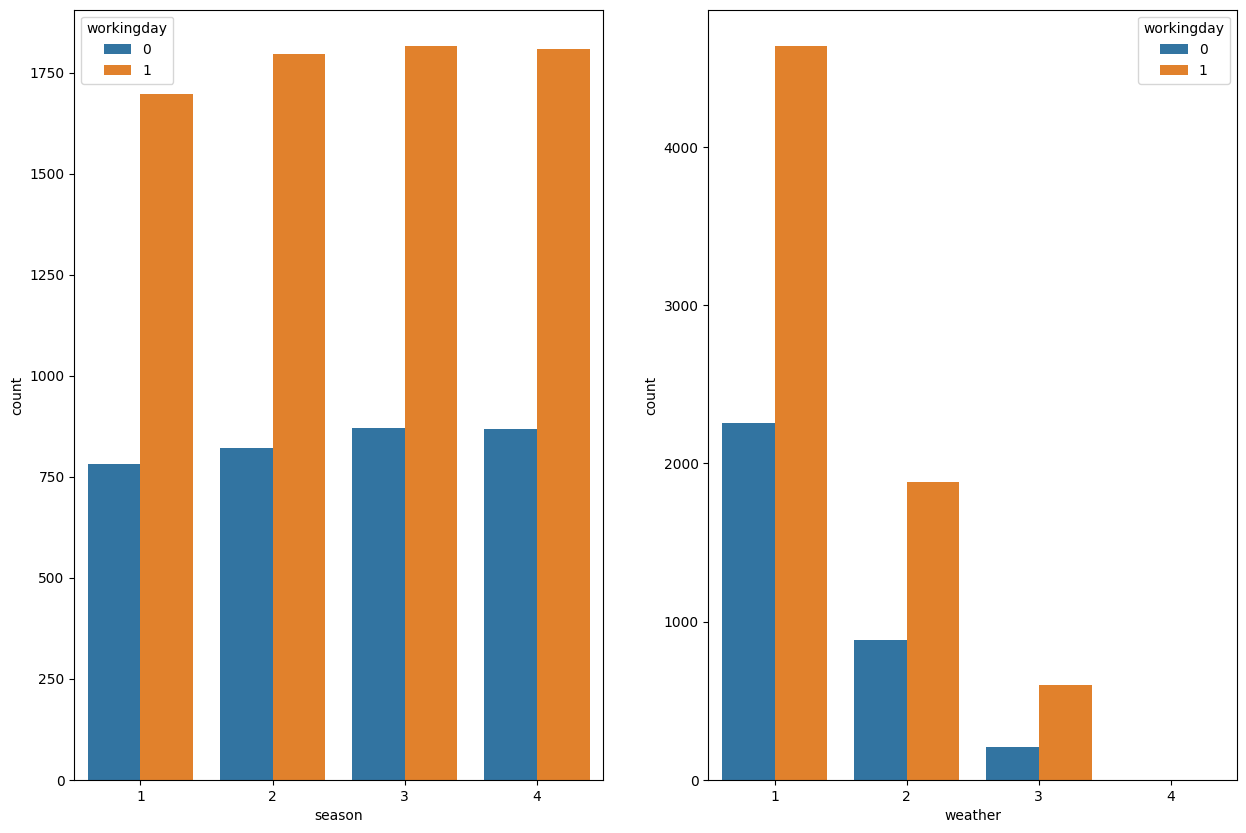

In [143]:

plt.subplots(1,2,figsize=(15,10))

plt.subplot(1,2,1)
sns.countplot(data = df,x = 'season',hue = 'workingday')

plt.subplot(1,2,2)
sns.countplot(data = df,x = 'weather',hue = 'workingday')

plt.show()

### Inferences from Count Plots with Hue (Workingday)

*   **Season vs. Workingday:** The countplots show that for all seasons, the number of rentals is higher on working days compared to non-working days (holidays and weekends). This suggests that a significant portion of the demand comes from daily commuting or activities during the work week, regardless of the season.
*   **Weather vs. Workingday:** Similarly, across different weather conditions (excluding the rare heavy rain/snow), the rental counts are consistently higher on working days. This reinforces the idea that the need for transportation on working days drives demand more than leisure activities on non-working days, even in less ideal weather.

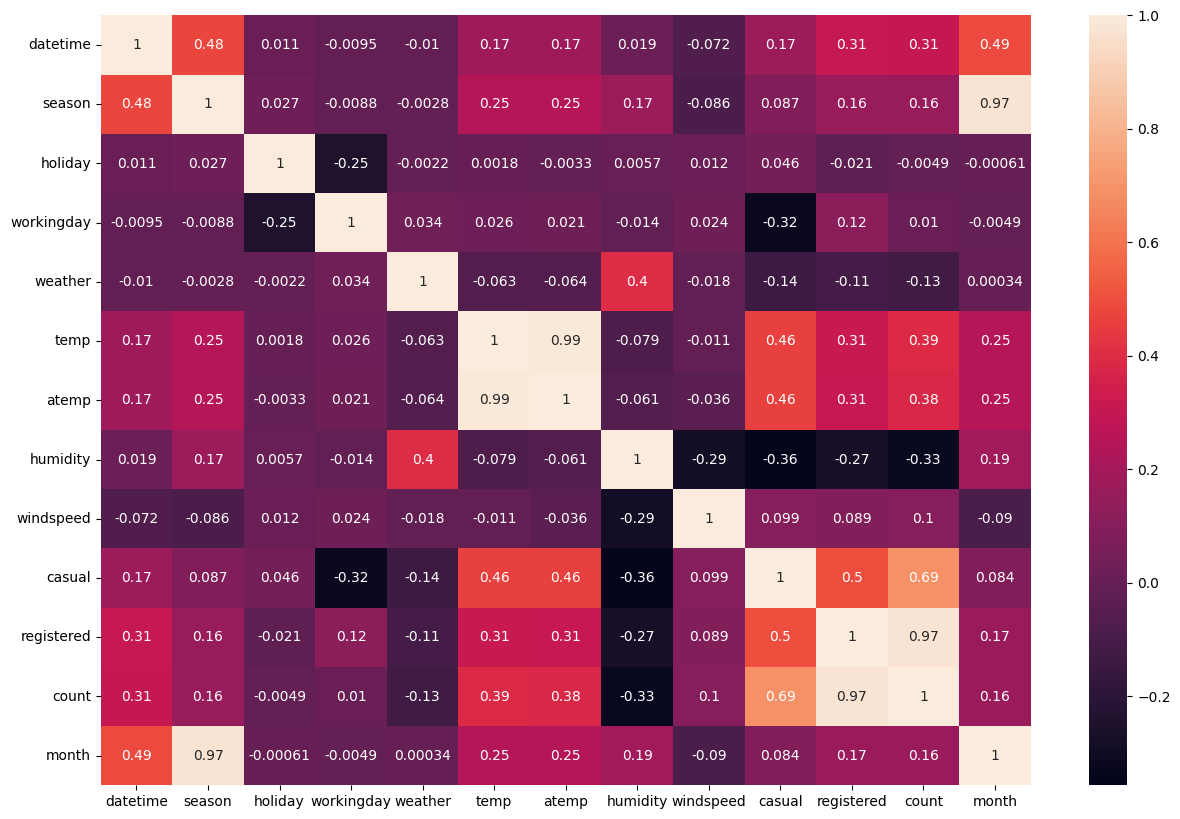

In [144]:
# lets look at the correlation using heatmap

plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot = True)
plt.show()

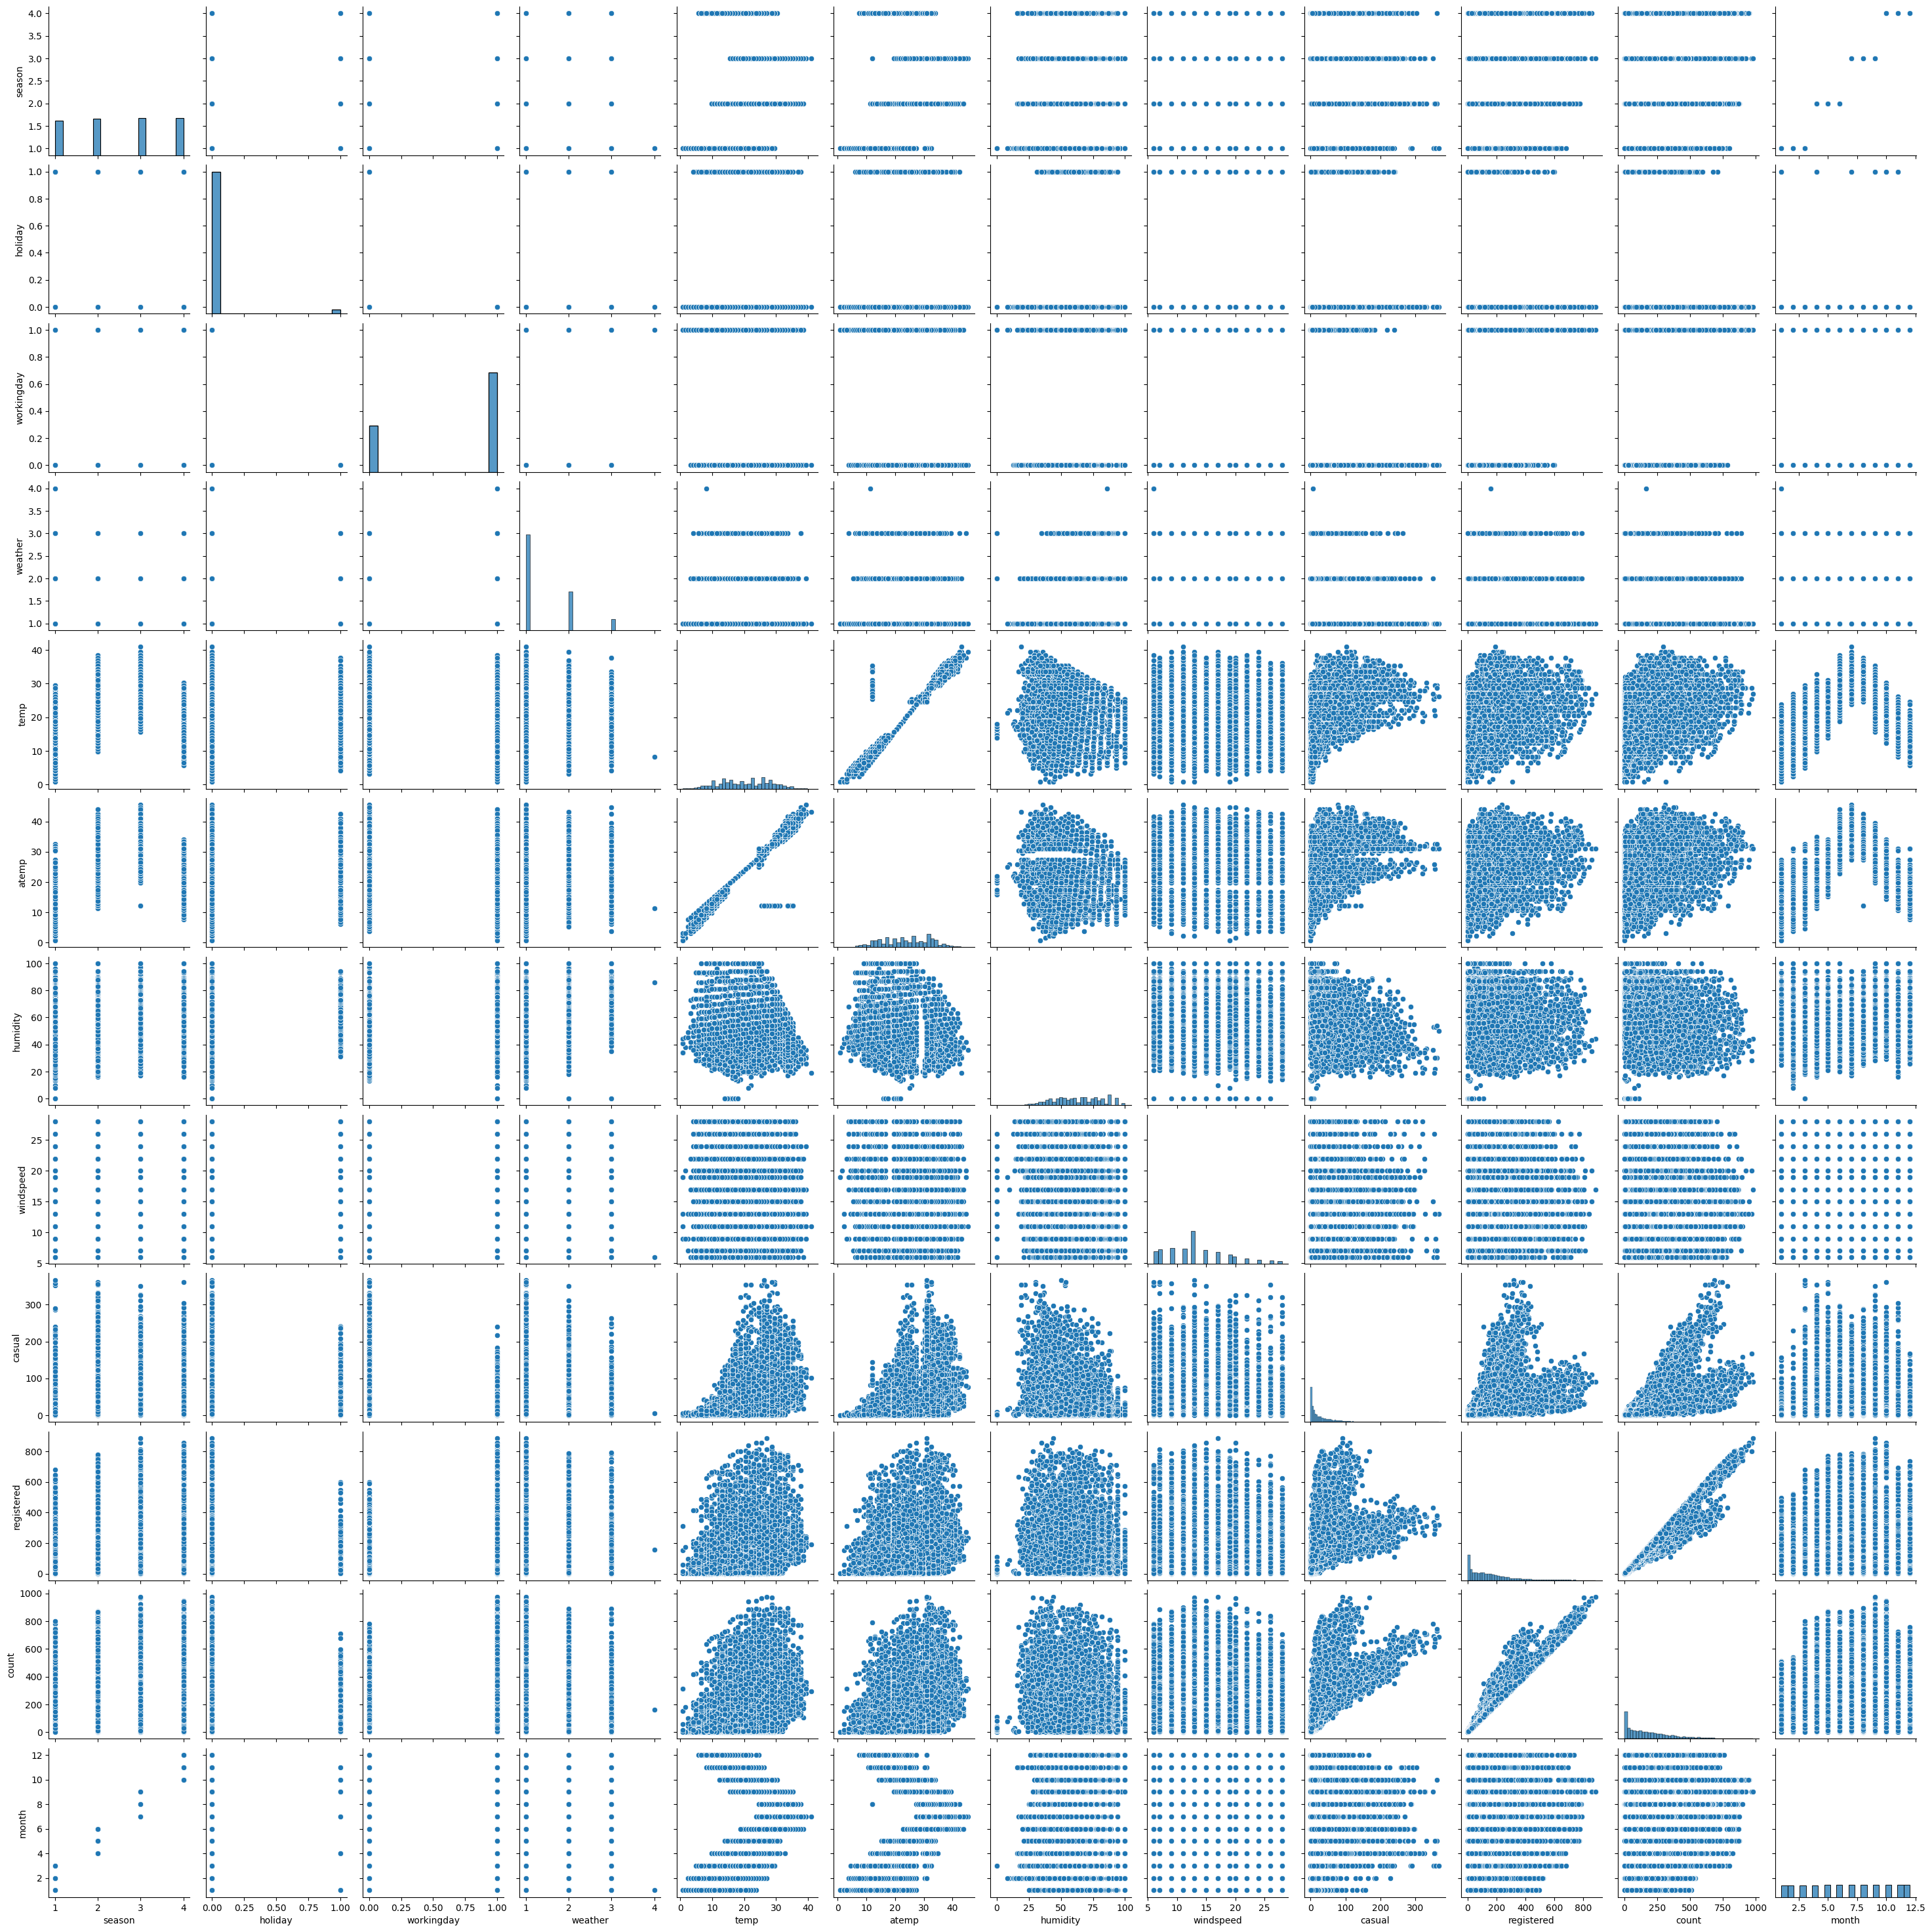

In [145]:
# lets look at the parplot also

sns.pairplot(df)
plt.show()


### Inferences from Heatmap and Pair Plot

*   **Strong Positive Correlation:** There is a strong positive correlation between `temp` and `atemp`, which is expected as 'atemp' is the 'feeling temperature' and is derived from temperature. There is also a strong positive correlation between `casual`, `registered`, and `count`, which is also expected as `count` is the sum of `casual` and `registered` users.
*   **Moderate Positive Correlation:** `count` shows a moderate positive correlation with `temp` and `atemp`, reinforcing the observation from scatter plots that demand increases with temperature. `registered` users also show a moderate positive correlation with `temp` and `atemp`.
*   **Weak or No Clear Correlation:** `humidity` and `windspeed` show weak or no clear linear correlation with `count`, `casual`, or `registered`. This aligns with the observations from the scatter plots.
*   **Categorical Variables:** The heatmap also shows some correlations between the numerical representation of categorical variables (`season`, `holiday`, `workingday`, `weather`) and the numerical variables. For example, `season` shows some correlation with `temp` and `atemp`, which is expected as temperature varies with seasons.
*   **Pair Plot Insights:** The pair plot visually confirms the relationships seen in the heatmap and scatter plots. It also shows the distributions of each variable (along the diagonal) and the pairwise relationships between all variables. It can be particularly useful for identifying non-linear relationships or clusters that might not be evident from the correlation coefficients alone.

# 4. Hypothesis Testing

In [150]:
# Working Day has effect on number of electric cycles rented

# Since its between numeric(cycles rented) and working day (categorical variable), I would be using z test

# Hypothesis Forming

H0 = " Number of cycles rented in working and non working day are not dependent"
H1 = " Number of cycles rented in working and non working day are dependent"


working_day_counts = df[df['workingday'] == 1]['count']
non_working_day_counts = df[df['workingday'] == 0]['count']

t_stat,p_value = ttest_ind(working_day_counts,non_working_day_counts)

print ("T-Stat",t_stat)
print("p-value",p_value)

# Setting Alpha at .05

alpha = .05

if p_value < alpha:
  print("Reject Null Hypothesis")
  print(H1)
else:
  print("Accept Null Hypothesis")
  print(H0)


T-Stat 1.0640563929642417
p-value 0.28732772342282314
Accept Null Hypothesis
 Number of cycles rented in working and non working day are not dependent


### Interpretation of T-Test Results (Working Day vs. Count)

Based on the independent samples t-test conducted to compare the mean number of cycles rented on working days versus non-working days:

*   **T-Statistic:** 1.064
*   **P-Value:** 0.287

With a significance level (alpha) of 0.05, the p-value (0.287) is greater than alpha. Therefore, we fail to reject the null hypothesis.

**Conclusion:** There is no statistically significant evidence to suggest that the mean number of electric cycles rented is different between working days and non-working days. This implies that, based on this test, the working day status does not have a significant effect on the overall number of electric cycles rented.

In [ ]:
#No. of cycles rented similar or different in different seasons

# In order to do this I will apply one-way ANOVA, but before that I will check for normality


In [153]:
season_1_counts = df[df['season'] == 1]['count']
season_2_counts = df[df['season'] == 2]['count']
season_3_counts = df[df['season'] == 3]['count']
season_4_counts = df[df['season'] == 4]['count']

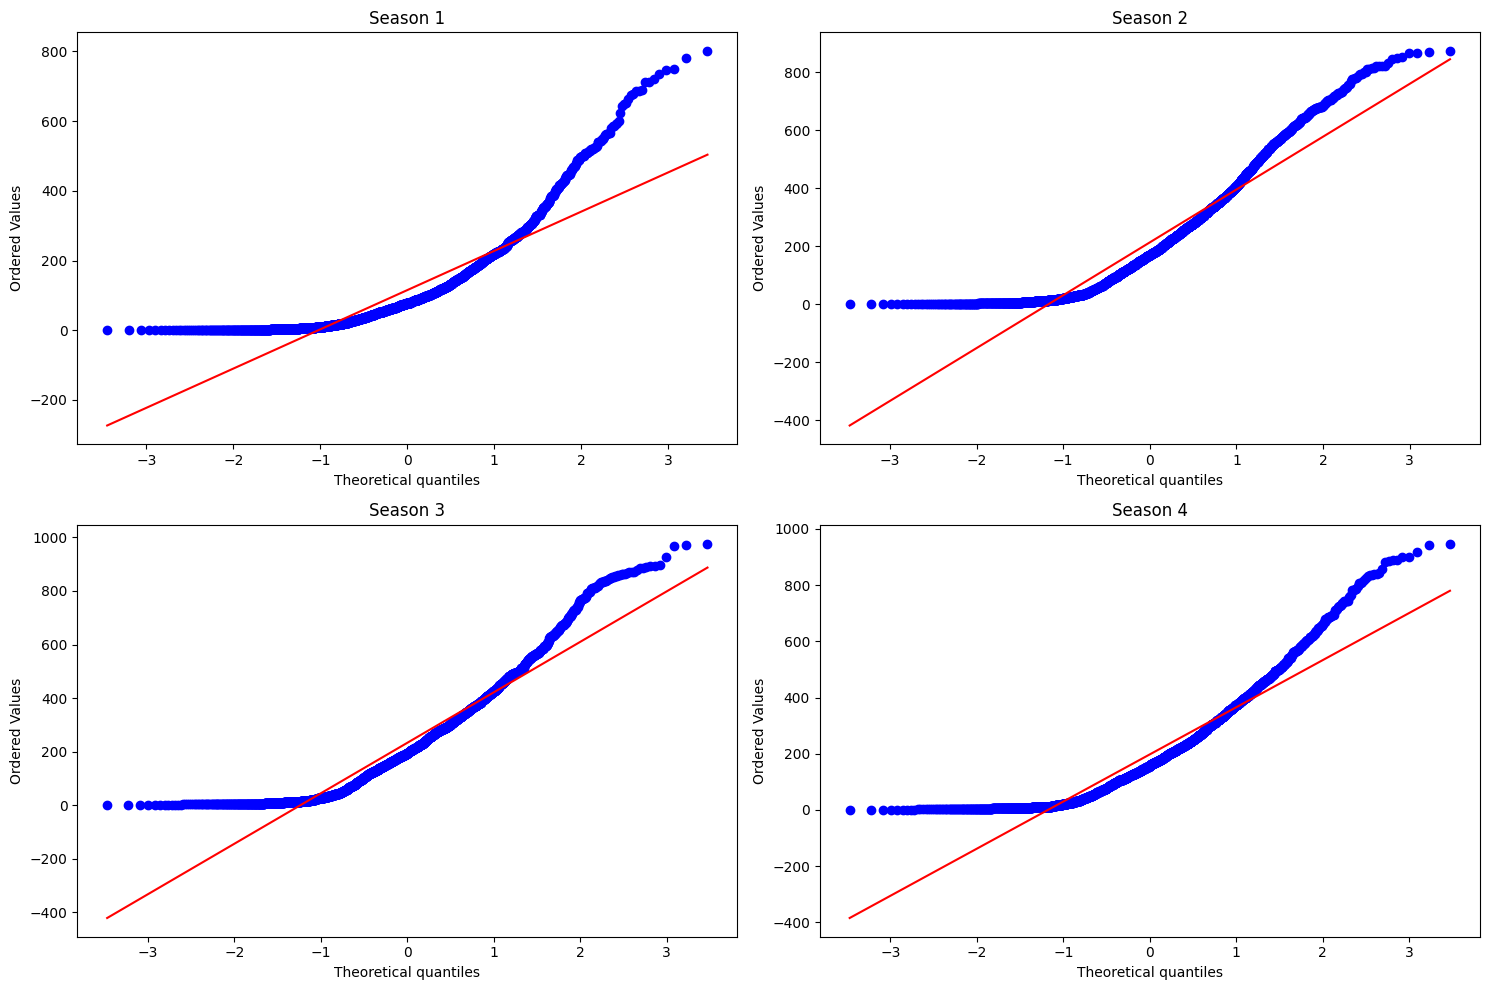

In [158]:
# Q-Q Plot using scipy.stats.probplot

import matplotlib.pyplot as plt
from scipy.stats import probplot

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

probplot(season_1_counts, dist="norm", plot=axes[0, 0])
axes[0, 0].set_title("Season 1")

probplot(season_2_counts, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("Season 2")

probplot(season_3_counts, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Season 3")

probplot(season_4_counts, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Season 4")

plt.tight_layout()
plt.show()

In [160]:
# Levene's test to check for the variance of the variables are equal


H0 = "The variances of the variables are equal"
H1 = "The variances of the variables are not equal"

levene_stat,p_value = levene(season_1_counts,season_2_counts,season_3_counts,season_4_counts)

print(levene_stat, p_value)

# Setting alpha at 0.05

if p_value < alpha:
  print("Reject Null Hypothesis")
  print(H1)
else:
  print("Accept Null Hypothesis")
  print(H0)

175.7301799940912 3.6972971685846006e-111
Reject Null Hypothesis
The variances of the variables are not equal


In [161]:
# So vvarainces are not equal and its normally distributes also, in this case I will use KW test

H0 = "The mean number of cycles rented is similar in different seasons."
H1 = "The mean number of cycles rented is different in different seasons."

stat,p_value = kruskal(season_1_counts,season_2_counts,season_3_counts,season_4_counts)

print(stat, p_value)

# Setting alpha at 0.05

if p_value < alpha:
  print("Reject Null Hypothesis")
  print(H1)
else:
  print("Accept Null Hypothesis")
  print(H0)

658.1384937388578 2.504949726738821e-142
Reject Null Hypothesis
The mean number of cycles rented is different in different seasons.


In [ ]:
# Perfoming ANOVA test as it was mentioned in the document to carry out the test irrespective of whether normality test is met or not

In [151]:
# Perform ANOVA test on 'count' vs 'season'

# Create a list of cycle counts for each season
season_1_counts = df[df['season'] == 1]['count']
season_2_counts = df[df['season'] == 2]['count']
season_3_counts = df[df['season'] == 3]['count']
season_4_counts = df[df['season'] == 4]['count']

# Perform one-way ANOVA test
f_statistic, p_value = f_oneway(season_1_counts, season_2_counts, season_3_counts, season_4_counts)

print("F-Statistic:", f_statistic)
print("P-Value:", p_value)

# Set alpha
alpha = 0.05

# Interpret the results
if p_value < alpha:
    print("Reject Null Hypothesis: The mean number of cycles rented is different in different seasons.")
else:
    print("Accept Null Hypothesis: The mean number of cycles rented is similar in different seasons.")

F-Statistic: 220.52120203655545
P-Value: 1.0113577584368538e-138
Reject Null Hypothesis: The mean number of cycles rented is different in different seasons.


### Interpretation of ANOVA Results (Season vs. Count)

Based on the one-way ANOVA test conducted to compare the mean number of cycles rented across different seasons:

*   **F-Statistic:** 220.52
*   **P-Value:** 1.01e-138 (a very small number close to zero)

With a significance level (alpha) of 0.05, the p-value (1.01e-138) is much less than alpha. Therefore, we reject the null hypothesis.

**Conclusion:** There is statistically significant evidence to suggest that the mean number of electric cycles rented is different in different seasons. This implies that the season *does* have a significant effect on the number of electric cycles rented, with some seasons having significantly higher or lower rental counts than others.

In [162]:
# No. of cycles rented similar or different in different weather

# In order to do this I will apply one-way ANOVA, but before that I will check for normality


In [163]:
weather_1_counts = df[df['weather'] == 1]['count']
weather_2_counts = df[df['weather'] == 2]['count']
weather_3_counts = df[df['weather'] == 3]['count']

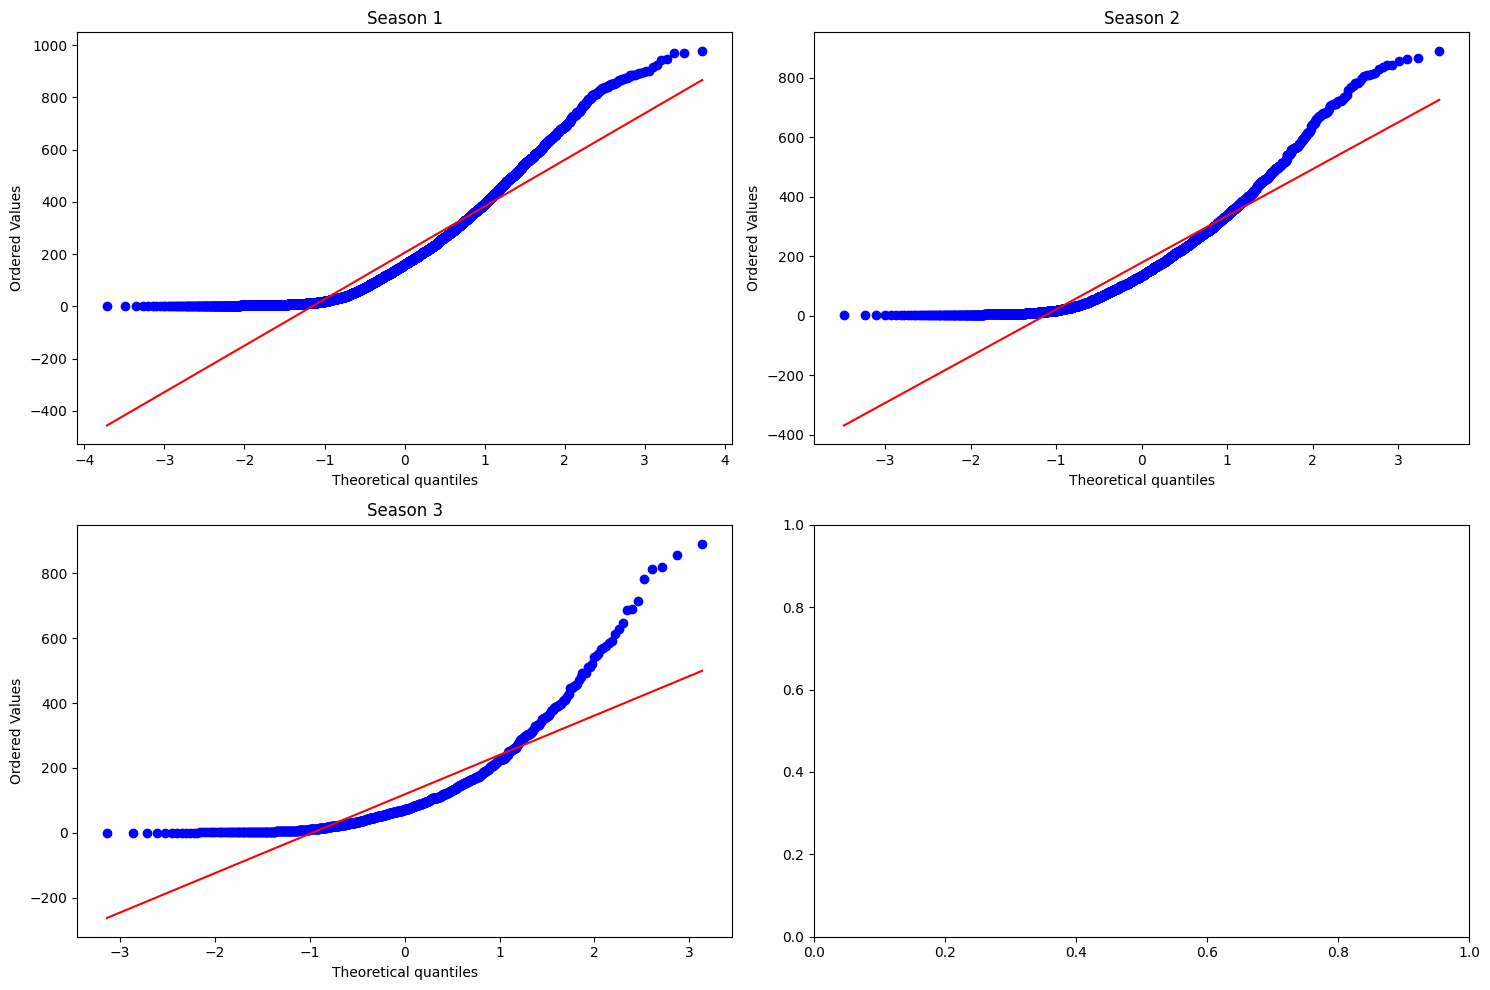

In [164]:
# Q-Q Plot using scipy.stats.probplot

import matplotlib.pyplot as plt
from scipy.stats import probplot

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

probplot(weather_1_counts, dist="norm", plot=axes[0, 0])
axes[0, 0].set_title("Season 1")

probplot(weather_2_counts, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("Season 2")

probplot(weather_3_counts, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Season 3")

plt.tight_layout()
plt.show()

In [165]:
# Levene's test to check for the variance of the variables are equal


H0 = "The variances of the variables are equal"
H1 = "The variances of the variables are not equal"

levene_stat,p_value = levene(weather_1_counts,weather_2_counts,weather_3_counts)

print(levene_stat, p_value)

# Setting alpha at 0.05

if p_value < alpha:
  print("Reject Null Hypothesis")
  print(H1)
else:
  print("Accept Null Hypothesis")
  print(H0)

81.15526125236282 1.0604854695827063e-35
Reject Null Hypothesis
The variances of the variables are not equal


In [166]:
# So vvarainces are not equal and its normally distributes also, in this case I will use KW test

H0 = "The mean number of cycles rented is similar in different weather."
H1 = "The mean number of cycles rented is different in different weathers."

stat,p_value = kruskal(weather_1_counts,weather_2_counts,weather_3_counts)

print(stat, p_value)

# Setting alpha at 0.05

if p_value < alpha:
  print("Reject Null Hypothesis")
  print(H1)
else:
  print("Accept Null Hypothesis")
  print(H0)

189.28879235036217 7.878816723238949e-42
Reject Null Hypothesis
The mean number of cycles rented is different in different weathers.


In [167]:
# Perfoming ANOVA test as it was mentioned in the document to carry out the test
# irrespective of whether normality test is met or not

In [152]:
# Perform ANOVA test on 'count' vs 'weather'

# Create a list of cycle counts for each weather condition
weather_1_counts = df[df['weather'] == 1]['count']
weather_2_counts = df[df['weather'] == 2]['count']
weather_3_counts = df[df['weather'] == 3]['count']
# weather_4_counts = df[df['weather'] == 4]['count'] # Excluded due to very few data points

# Perform one-way ANOVA test
f_statistic, p_value = f_oneway(weather_1_counts, weather_2_counts, weather_3_counts)

print("F-Statistic:", f_statistic)
print("P-Value:", p_value)

# Set alpha
alpha = 0.05

# Interpret the results
if p_value < alpha:
    print("Reject Null Hypothesis: The mean number of cycles rented is different in different weather conditions.")
else:
    print("Accept Null Hypothesis: The mean number of cycles rented is similar in different weather conditions.")

F-Statistic: 92.80113005231262
P-Value: 1.1234208164674595e-40
Reject Null Hypothesis: The mean number of cycles rented is different in different weather conditions.


### Interpretation of ANOVA Results (Weather vs. Count)

Based on the one-way ANOVA test conducted to compare the mean number of cycles rented across different weather conditions:

*   **F-Statistic:** 92.80
*   **P-Value:** 1.12e-40 (a very small number close to zero)

With a significance level (alpha) of 0.05, the p-value (1.12e-40) is much less than alpha. Therefore, we reject the null hypothesis.

**Conclusion:** There is statistically significant evidence to suggest that the mean number of electric cycles rented is different in different weather conditions. This implies that the weather *does* have a significant effect on the number of electric cycles rented, with some weather conditions leading to significantly higher or lower rental counts than others. Notably, weather condition 4 was excluded from this test due to insufficient data points, but based on the remaining categories, weather is a significant factor.

In [ ]:
# Weather is dependent on season (check between 2 predictor variable)

# Since both are categorical variables, I would be using Chi-square test for independecne



In [168]:
# Perform Chi-square test for independence on 'weather' and 'season'

# Create a contingency table of 'weather' and 'season'
contingency_table = pd.crosstab(df['weather'], df['season'])

# Perform Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("P-value:", p)
print("Degrees of freedom:", dof)
# print("Expected frequencies table:", expected) # Uncomment to see the expected frequencies

# Set alpha
alpha = 0.05

# Interpret the results
if p < alpha:
    print("Reject Null Hypothesis: Weather is dependent on season.")
else:
    print("Accept Null Hypothesis: Weather is independent of season.")

Chi-square statistic: 55.29873806102515
P-value: 1.0682692671386608e-08
Degrees of freedom: 9
Reject Null Hypothesis: Weather is dependent on season.


### Interpretation of Chi-square Test Results (Weather vs. Season)

Based on the Chi-square test for independence conducted to examine the relationship between weather and season:

*   **Chi-square statistic:** 55.30
*   **P-value:** 1.07e-08 (a very small number close to zero)
*   **Degrees of freedom:** 9

With a significance level (alpha) of 0.05, the p-value (1.07e-08) is much less than alpha. Therefore, we reject the null hypothesis.

**Conclusion:** There is statistically significant evidence to suggest that weather is dependent on the season. This means that the distribution of different weather conditions is not the same across all seasons, and certain weather types are more likely to occur in specific seasons. This finding is also intuitively understandable, as weather patterns naturally vary with the time of year.

# Inferences from the Analysis & Recommendations

# Recommendations

Based on the analysis, the following recommendations can be made to Yulu:

*   **Season and Weather are significant factors affecting demand:** The ANOVA tests showed that both season and weather conditions have a statistically significant impact on the number of cycles rented. This suggests that Yulu should tailor its strategies based on these factors. For example, they could increase the availability of bikes during peak seasons (summer and fall) and in favorable weather conditions (clear, few clouds). Conversely, they might consider reducing the fleet size or offering promotions during off-peak seasons (winter and spring) or in adverse weather.
*   **Working day status does not show a statistically significant effect:** The t-test indicated that there is no statistically significant difference in the mean number of cycles rented between working days and non-working days. While the count plots show a higher raw count on working days, this might be due to the sheer number of working days compared to non-working days in the dataset. This finding suggests that Yulu's current operational strategy regarding working days versus non-working days might not need significant adjustments based solely on this factor. However, further investigation into hourly demand patterns on working vs. non-working days could provide more nuanced insights.
*   **Temperature has a positive correlation with demand:** The scatter plot and heatmap indicated a moderate positive correlation between temperature and rental count. Yulu should anticipate higher demand during warmer periods and ensure adequate bike availability.
*   **Humidity and Windspeed have weak or no clear correlation with demand:** The analysis did not reveal strong linear relationships between humidity and windspeed and the rental count. While extreme conditions might still have an impact, these factors appear less significant drivers of overall demand compared to season, weather, and temperature.
*   **Focus on registered users:** The analysis showed that registered users contribute significantly more to the total rental count than casual users. Yulu could focus on strategies to increase registered users and encourage repeat usage, such as loyalty programs or subscription benefits.
*   **Address zero windspeed values:** While we imputed the zero windspeed values with the median for the analysis, it would be beneficial to understand why these zero values exist in the data. Future data collection should aim to record accurate wind speed data.
*   **Consider hourly patterns:** The current analysis primarily focused on daily patterns. Analyzing hourly rental patterns could provide more granular insights into peak usage times within a day, which could inform dynamic pricing or bike redistribution strategies.

By considering these factors, Yulu can make more informed decisions to optimize its operations, improve demand, and ultimately increase revenue.